## Installing packages

In [ ]:
!pip install openslide-python kfbslide
!pip install openslide-bin

## Setup

In [ ]:
import openslide, kfbslide
import numpy as np
import time
from pathlib import Path
from skimage.filters import threshold_otsu
from skimage.color import rgb2hsv

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

root_dir = "/content/drive/MyDrive/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
slide_name = "2024-10-14_08_29_15CYT"
slide_path = root_dir + slide_name + ".kfb"
save_path = root_dir + slide_name

## Extraction pipeline

In [ ]:
def extract_tiles(slide_path, save_path, tile_size=224):
    # Abertura da lâmina e verificação de magnificação 20x
    s = kfbslide.OpenSlide(Path(slide_path))
    if int(s.properties.get("openslide.objective-power")) != 40:
        s.close()
        return
    if int(s.level_downsamples[1]) != 2:
        s.close()
        return

    # Otsu na lâmina toda (miniatura)
    lv_thumb = s.get_best_level_for_downsample(32)
    thumb = s.read_region((0, 0), lv_thumb, s.level_dimensions[lv_thumb]).convert("L")
    thr = threshold_otsu(np.asarray(thumb))
    total_area = tile_size * tile_size

    # Pasta de saída
    out_dir = Path(save_path)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Extração de tiles
    level = 1
    step = tile_size * 2
    W, H = s.dimensions
    count = 0
    for y in range(0, H-step+1, step):
        for x in range(0, W-step+1, step):

            region = s.read_region((x, y), level, (tile_size, tile_size))
            if np.asarray(region)[..., 3].min() == 0:
                continue
            img = region.convert("RGB")

            gray = np.asarray(img.convert("L"))
            mask = gray < thr

            cell_area = mask.sum()
            if (cell_area / total_area) < 0.20:
              continue

            # Evita tiles 'sujos'
            px = np.asarray(img)[mask].reshape(-1, 1, 3)
            if np.median(rgb2hsv(px / 255.0)[..., 0]) * 360 < 180:
              continue

            img.save(out_dir / (str(count) + ".png"))
            count += 1

    s.close()

In [ ]:
extract_tiles(slide_path=slide_path, save_path=save_path)

## Loading UniCAS

In [ ]:
'''
Credits:
https://github.com/peter-fei/UniCAS
'''

import functools
import torch
import timm

# Define UniCAS parameters
params = {
    'patch_size': 16,
    'embed_dim': 1024,
    'depth': 24,
    'num_heads': 16,
    'init_values': 1e-5,
    'mlp_ratio': 2.671875 * 2,
    'mlp_layer': functools.partial(timm.layers.mlp.GluMlp, gate_last=False),
    'act_layer': torch.nn.SiLU,
    'no_embed_class': False,
    'img_size': 224,
    'num_classes': 0,
    'in_chans': 3,
}

# Build model
model = timm.models.VisionTransformer(**params)

# Load checkpoint
# Ensure 'UniCAS.pth' is in your current directory
state = torch.load(root_dir + '/' + 'UniCAS.pth', map_location='cpu')
print(model.load_state_dict(state, strict=False))

# Inference example
model.eval()
if torch.cuda.is_available():
    model = model.cuda()

with torch.no_grad():
    # Input: [Batch, Channels, Height, Width]
    x = torch.randn(1, 3, 224, 224)
    if torch.cuda.is_available():
        x = x.cuda()
    out = model(x)
    print('Output feature shape:', out.shape) # Expected: [1, 1024]

<All keys matched successfully>
Output feature shape: torch.Size([1, 1024])


## Evaluation setup

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()
print("",end="")

## Dataset

In [ ]:
from torch.utils.data import Dataset
from torchvision.io import decode_image

class Slides(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return 2006

    def __getitem__(self, idx):
        img_path = self.img_dir + f"/{idx}.png"
        image = decode_image(img_path)
        if self.transform:
            image = self.transform(image)
        return image

In [ ]:
from torchvision.transforms import v2

transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True), v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])

In [ ]:
# data = Slides(img_dir=root_dir + slide_name, transform=transform) // Drive
data = Slides(img_dir='/content/' + slide_name, transform=transform)

## Embedding test on an in-house sample

In [ ]:
sample = data[0].unsqueeze(0)
print(sample.shape)

torch.Size([1, 3, 224, 224])


In [ ]:
with torch.no_grad():
  sample = sample.to(device)
  embedding = model(sample)
  print("Embedding:", embedding)
  print("Shape:", embedding.shape)

Embedding: tensor([[-1.4441,  0.5796, -0.3572,  ..., -0.2797,  0.0314, -1.6227]],
       device='cuda:0')
Shape: torch.Size([1, 1024])


## Dataloader

In [ ]:
from torch.utils.data import DataLoader

dataloader = DataLoader(data, batch_size=64)

## Embedding extraction

In [ ]:
from tqdm import tqdm

embeddings = []
with torch.no_grad():
  for X in tqdm(dataloader):  # X [64,3,224,224]
    X = X.to(device)
    embedding = model(X)
    embeddings.append(embedding.cpu())

100%|██████████| 32/32 [01:22<00:00,  2.57s/it]


In [ ]:
all_embeddings = torch.cat(embeddings, dim=0)
torch.save(all_embeddings, root_dir + 'embeddings.pt')

## tsne-cuda (https://github.com/CannyLab/tsne-cuda)

In [ ]:
!pip install -q condacolab
import condacolab; condacolab.install()   # reinicia o kernel sozinho

In [ ]:
!conda install -q -y -c conda-forge tsnecuda

In [ ]:
from tsnecuda import TSNE
import numpy as np
import torch

embeddings = torch.load(root_dir + "embeddings.pt", map_location="cpu")
X_tsne = TSNE(n_components=2, perplexity=30, learning_rate=500).fit_transform(embeddings.detach().cpu().numpy().astype(np.float32))

In [ ]:
print(X_tsne.shape)

(2006, 2)


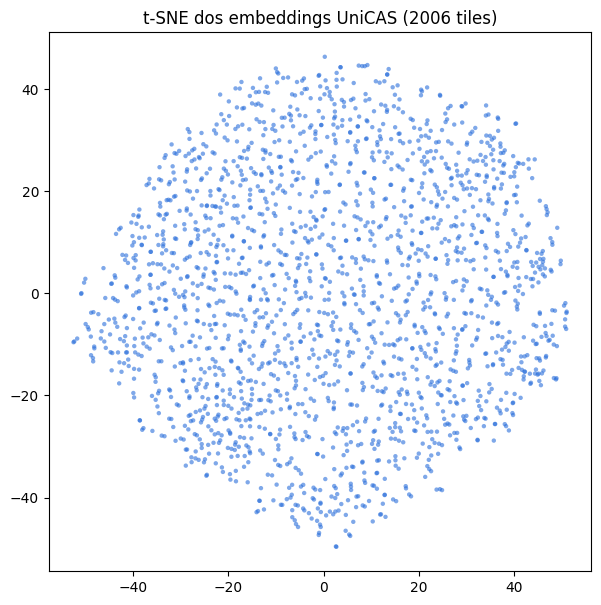

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], s=10, alpha=0.6, color="#2a6fdb", edgecolors="none")
plt.title(f"t-SNE dos embeddings UniCAS ({len(X_tsne)} tiles)")
plt.show()

In [ ]:
import torch.nn.functional as F

# Similaridade de cosseno entre todos os pares de tiles
E = F.normalize(embeddings.float(), dim=1)
S = (E @ E.T).numpy()
pares = S[np.triu_indices(len(S), k=1)]

print(f"Similaridade de cosseno entre pares: média {pares.mean():.3f} ± {pares.std():.3f} "
      f"(mín {pares.min():.3f}, máx {pares.max():.3f})")

Similaridade de cosseno entre pares: média 0.266 ± 0.089 (mín -0.038, máx 0.803)
